In [10]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [11]:
load_dotenv()

True

In [12]:
model =   ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")


In [13]:
MAX_TOKENS = 150

In [14]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [15]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [16]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

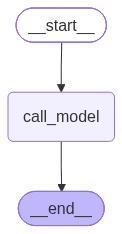

In [17]:
graph

In [18]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Suman."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Suman.


[{'type': 'text',
  'text': "Hello, Suman! It's nice to meet you. How are you doing today? Is there anything I can help you with?",
  'extras': {'signature': 'EnEKbwERTTIP28e7CIs9NnH5QxBypdhWlRLdv95miqp9N2OHa2tjAQnRIz2LCtiqeIMz6nILAyaKGG/7x64iRGFuF4uRhN8mGqXLFF+CU6T/BKxL3oLzLWipO1KuYEzvRdWi6mmCuLd6JQxUh/tXoi5V/g=='}}]

In [19]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 51
Hi, my name is Suman.
[{'type': 'text', 'text': "Hello, Suman! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EnEKbwERTTIP28e7CIs9NnH5QxBypdhWlRLdv95miqp9N2OHa2tjAQnRIz2LCtiqeIMz6nILAyaKGG/7x64iRGFuF4uRhN8mGqXLFF+CU6T/BKxL3oLzLWipO1KuYEzvRdWi6mmCuLd6JQxUh/tXoi5V/g=='}}]
I am learning LangGraph.


[{'type': 'text',
  'text': 'That’s a fantastic choice! LangGraph is currently one of the most powerful ways to build agentic workflows because it moves beyond simple chains and allows for true **cycles, state management, and human-in-the-loop control.**\n\nTo help you get started or deepen your understanding, where are you currently in your learning journey?\n\nHere are a few ways I can help you:\n\n1.  **Core Concepts:** Are you familiar with the basic building blocks yet? (e.g., `StateGraph`, `Nodes`, `Edges`, `Checkpointers`, and `State`.)\n2.  **Architecture:** Do you have a specific use case in mind? (e.g., a chatbot that can search the web, an autonomous research agent, or a multi-agent system?)\n3.  **Code Examples:** Would you like to see a "Hello World" of LangGraph, or perhaps something more advanced like a loop with conditional logic?\n4.  **Debugging/Troubleshooting:** Are you stuck on a specific error or a conceptual hurdle regarding how state is updated?\n\n**If you\'re 

In [20]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


[{'type': 'text',
  'text': 'Short-term memory (STM), often referred to as **"working memory,"** is the brain\'s system for temporarily holding a small amount of information in an active, readily available state.\n\nThink of it as a **mental scratchpad** or a **RAM stick** in a computer: it’s where you keep information that you need to use *right now*, before either discarding it or moving it into long-term storage.\n\nHere is a breakdown of how it works:\n\n---\n\n### 1. The Capacity: "The Magical Number Seven"\nFor decades, psychologists believed the capacity of short-term memory was limited to about **7 items (plus or minus 2)**. \n*   **Example:** If someone lists 10 random words to you, you will likely remember the ones at the beginning and the end, but struggle to hold all 10 in your head at once. \n*   **Chunking:** We can increase this capacity by grouping information. For example, trying to remember the string `1-9-8-4-2-0-2-4` is hard. But if you group it as `1984` and `2024`

As at the last message we exceed our token count . So we have to trim the last messages . So the llm didnot know the my name Although at the beginning we told it. This is how trimming removes the messages older . It is done with assumptions that recent messages are important. 

we can see it here as the name is neccessary . So trimming is not good technique . So Summarization techniques are used to not lose the important information . 

In [21]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 8
What is my name?


[{'type': 'text',
  'text': 'I don’t know your name. As an AI, I don’t have access to your personal identity, private documents, or webcam unless you have previously shared that information with me in this specific conversation.',
  'extras': {'signature': 'EnEKbwERTTIP0qnEyXtzrRjeVEXKUj2XsI+cF2KcY4IkRhzbk8OXfBwze2lMWw0OSWC2EChJLRqz/1IZRjS8nw/JGN+Za+IFhKcKSa5cnMRl5cgP6R36rajfRmqHnWDzU8vReRJUEnH2yhyL6wlwIoabng=='}}]

In [22]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Suman.
------------------------------------------------------------------------------------------------------------------------
[{'type': 'text', 'text': "Hello, Suman! It's nice to meet you. How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EnEKbwERTTIP28e7CIs9NnH5QxBypdhWlRLdv95miqp9N2OHa2tjAQnRIz2LCtiqeIMz6nILAyaKGG/7x64iRGFuF4uRhN8mGqXLFF+CU6T/BKxL3oLzLWipO1KuYEzvRdWi6mmCuLd6JQxUh/tXoi5V/g=='}}]
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
[{'type': 'text', 'text': 'That’s a fantastic choice! LangGraph is currently one of the most powerful ways to build agentic workflows because it moves beyond simple chains and allows for true **cycles, state management, and human-in-the-loop control.**\n\nTo help you get st